# Construction pédagogique du graphe de voisins

Cette étape reproduit la PCA validée puis construit uniquement un graphe de voisins non corrigé. Aucun UMAP ni clustering n'est calculé.

In [1]:
from copy import deepcopy
from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import sparse
from scipy.sparse.csgraph import connected_components
from IPython.display import Markdown, display

## Chargement de l'objet log-normalisé

In [2]:
input_path = Path("../data/processed/GSE149689_log_normalized.h5ad")
adata = sc.read_h5ad(input_path)
print(adata)
print("Dimensions :", adata.shape)

AnnData object with n_obs × n_vars = 58825 × 33538
    obs: 'sample_id', 'subject_id', 'disease', 'severity', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'log1p'
    layers: 'counts'
Dimensions : (58825, 33538)


## Reproduction de la PCA validée

Le scaling est appliqué uniquement à une copie des 2 000 HVG. L'expression log-normalisée des 33 538 gènes dans adata.X n'est pas modifiée.

In [3]:
adata_hvg = adata[:, adata.var["highly_variable"]].copy()
if adata_hvg.shape != (58825, 2000):
    raise AssertionError(f"Dimensions HVG inattendues : {adata_hvg.shape}")

sc.pp.scale(
    adata_hvg,
    zero_center=True,
    max_value=10,
)
sc.pp.pca(
    adata_hvg,
    n_comps=50,
    svd_solver="arpack",
    random_state=42,
)

adata.obsm["X_pca"] = adata_hvg.obsm["X_pca"].copy()
adata.uns["pca"] = deepcopy(adata_hvg.uns["pca"])
print("Scores PCA transférés vers l'objet complet :", adata.obsm["X_pca"].shape)
print("adata.X reste non scalé et sparse :", sparse.issparse(adata.X))

/home/momo/miniconda3/envs/scrna/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Scores PCA transférés vers l'objet complet : (58825, 50)
adata.X reste non scalé et sparse : True


## Contrôles avant construction du graphe

In [4]:
n_cells_before_neighbors = adata.n_obs
pre_neighbor_checks = {
    "dimensions_58825_x_33538": adata.shape == (58825, 33538),
    "counts_layer_present": "counts" in adata.layers,
    "exactly_2000_HVG": int(adata.var["highly_variable"].sum()) == 2000,
    "X_pca_shape_58825_x_50": adata.obsm["X_pca"].shape == (58825, 50),
    "X_pca_all_finite": bool(np.isfinite(adata.obsm["X_pca"]).all()),
}
display(pd.Series(pre_neighbor_checks, name="passed").to_frame())
if not all(pre_neighbor_checks.values()):
    raise AssertionError(f"Échec des contrôles avant neighbors : {pre_neighbor_checks}")

,passed
dimensions_58825_x_33538,True
counts_layer_present,True
exactly_2000_HVG,True
X_pca_shape_58825_x_50,True
X_pca_all_finite,True


## Graphe de voisins non corrigé

Le graphe utilise les 20 premières composantes principales. n_neighbors=15 définit la taille locale utilisée pour estimer les voisinages; aucune correction de batch n'est appliquée.

In [5]:
sc.pp.neighbors(
    adata,
    n_neighbors=15,
    n_pcs=20,
    random_state=42,
)

/home/momo/miniconda3/envs/scrna/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Objets créés dans AnnData

In [6]:
print("adata.uns['neighbors'] :")
print(adata.uns["neighbors"])

distances = adata.obsp["distances"]
connectivities = adata.obsp["connectivities"]
neighbor_objects = pd.DataFrame({
    "object": ["distances", "connectivities"],
    "shape": [distances.shape, connectivities.shape],
    "type": [type(distances).__name__, type(connectivities).__name__],
    "stored_nnz": [distances.nnz, connectivities.nnz],
    "strictly_nonzero_values": [distances.count_nonzero(), connectivities.count_nonzero()],
})
display(neighbor_objects)
print("Nombre de cellules inchangé :", adata.n_obs == n_cells_before_neighbors)

display(Markdown(
    "adata.uns['neighbors'] conserve les paramètres et les clés du graphe. "
    "adata.obsp['distances'] contient les distances entre voisins retenus, tandis que "
    "adata.obsp['connectivities'] contient les poids de connectivité du graphe symétrisé."
))

adata.uns['neighbors'] :
{'connectivities_key': 'connectivities', 'distances_key': 'distances', 'params': {'n_neighbors': 15, 'method': 'umap', 'random_state': 42, 'metric': 'euclidean', 'n_pcs': 20}}


,object,shape,type,stored_nnz,strictly_nonzero_values
0,distances,"(58825, 58825)",csr_matrix,941200,882375
1,connectivities,"(58825, 58825)",csr_matrix,1224620,1224620


Nombre de cellules inchangé : True


adata.uns['neighbors'] conserve les paramètres et les clés du graphe. adata.obsp['distances'] contient les distances entre voisins retenus, tandis que adata.obsp['connectivities'] contient les poids de connectivité du graphe symétrisé.

## Statistiques descriptives du graphe

In [7]:
unweighted_degree = np.asarray((connectivities > 0).sum(axis=1)).ravel()
weighted_degree = np.asarray(connectivities.sum(axis=1)).ravel()

def describe_vector(values):
    return pd.Series({
        "min": np.min(values),
        "Q1": np.quantile(values, 0.25),
        "median": np.median(values),
        "mean": np.mean(values),
        "Q3": np.quantile(values, 0.75),
        "max": np.max(values),
    })

degree_summary = pd.concat({
    "unweighted_degree": describe_vector(unweighted_degree),
    "weighted_degree": describe_vector(weighted_degree),
}, axis=1)
display(degree_summary)

n_components, component_labels = connected_components(connectivities, directed=False)
positive_distances = distances.data[distances.data > 0]
graph_summary = pd.Series({
    "n_cells": adata.n_obs,
    "distance_stored_nnz": distances.nnz,
    "distance_strictly_nonzero_values": distances.count_nonzero(),
    "connectivity_stored_nnz": connectivities.nnz,
    "connectivity_strictly_nonzero_values": connectivities.count_nonzero(),
    "connectivity_density_percent": 100 * connectivities.nnz / (adata.n_obs ** 2),
    "isolated_cells": int((unweighted_degree == 0).sum()),
    "connected_components": int(n_components),
    "distance_min_positive": float(positive_distances.min()),
    "distance_median_positive": float(np.median(positive_distances)),
    "distance_max_positive": float(positive_distances.max()),
}, name="value")
display(graph_summary.to_frame())

,unweighted_degree,weighted_degree
min,14.00000,3.906880
Q1,16.00000,4.836113
median,19.00000,5.919151
mean,20.81802,6.572508
Q3,23.00000,7.592359
max,122.00000,34.636753


,value
n_cells,5.882500e+04
distance_stored_nnz,9.412000e+05
distance_strictly_nonzero_values,8.823750e+05
connectivity_stored_nnz,1.224620e+06
connectivity_strictly_nonzero_values,1.224620e+06
connectivity_density_percent,3.538975e-02
isolated_cells,0.000000e+00
connected_components,1.000000e+00
distance_min_positive,8.630758e-01
distance_median_positive,4.055756e+00


## Résumé

sc.pp.neighbors() a créé deux matrices sparse cellule × cellule dans adata.obsp : distances pour les distances locales retenues et connectivities pour les poids du graphe symétrisé. Les paramètres et les clés correspondantes sont enregistrés dans adata.uns['neighbors']. Ce graphe est non corrigé et repose sur les 20 premières PC de la PCA validée. Aucun UMAP, Leiden, clustering, filtrage ou test différentiel n'a été réalisé.

## Premier UMAP non corrigé

L'UMAP est calculé une seule fois à partir du graphe validé (15 voisins, 20 PC), sans correction de batch. Seule la graine aléatoire est explicitée; les autres paramètres Scanpy restent à leurs valeurs par défaut, notamment min_dist=0.5, spread=1.0, n_components=2 et init_pos='spectral'.

In [8]:
neighbor_params = adata.uns["neighbors"]["params"]
graph_checks_before_umap = {
    "neighbors_present": "neighbors" in adata.uns,
    "distances_present": "distances" in adata.obsp,
    "connectivities_present": "connectivities" in adata.obsp,
    "n_neighbors_15": neighbor_params.get("n_neighbors") == 15,
    "n_pcs_20": neighbor_params.get("n_pcs") == 20,
}
display(pd.Series(graph_checks_before_umap, name="passed").to_frame())
if not all(graph_checks_before_umap.values()):
    raise AssertionError(f"Le graphe attendu n'est pas disponible : {graph_checks_before_umap}")

,passed
neighbors_present,True
distances_present,True
connectivities_present,True
n_neighbors_15,True
n_pcs_20,True


In [9]:
sc.tl.umap(
    adata,
    random_state=42,
)

umap_coordinates = adata.obsm["X_umap"]
umap_checks = {
    "X_umap_present": "X_umap" in adata.obsm,
    "X_umap_shape_58825_x_2": umap_coordinates.shape == (58825, 2),
    "X_umap_all_finite": bool(np.isfinite(umap_coordinates).all()),
    "cell_count_unchanged": adata.n_obs == n_cells_before_neighbors == 58825,
    "neighbors_still_present": "neighbors" in adata.uns and "connectivities" in adata.obsp,
}
display(pd.Series(umap_checks, name="passed").to_frame())
if not all(umap_checks.values()):
    raise AssertionError(f"Échec des contrôles UMAP : {umap_checks}")
print("Dimensions X_umap :", umap_coordinates.shape)
print("UMAP calculé une seule fois; ces coordonnées seront réutilisées pour toutes les figures.")

,passed
X_umap_present,True
X_umap_shape_58825_x_2,True
X_umap_all_finite,True
cell_count_unchanged,True
neighbors_still_present,True


Dimensions X_umap : (58825, 2)
UMAP calculé une seule fois; ces coordonnées seront réutilisées pour toutes les figures.


## Colorations des mêmes coordonnées UMAP

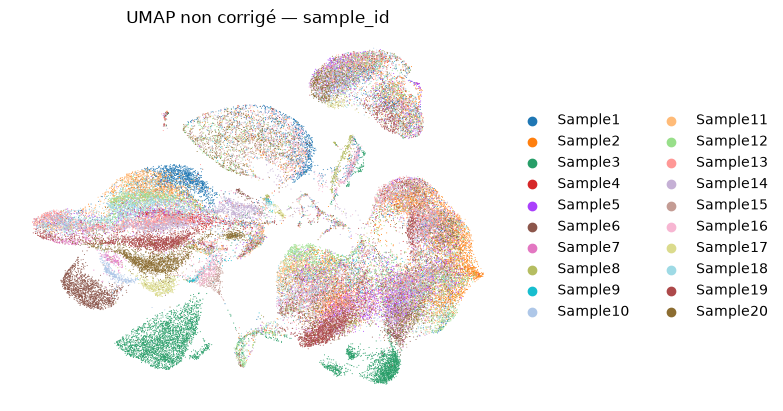

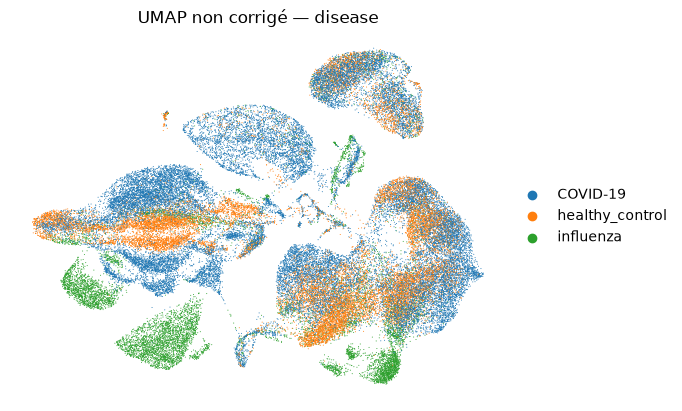

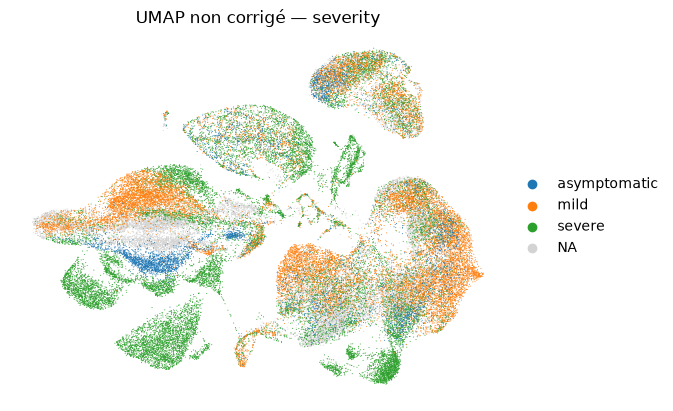

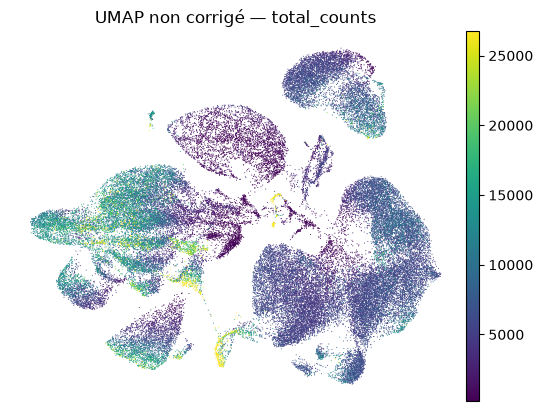

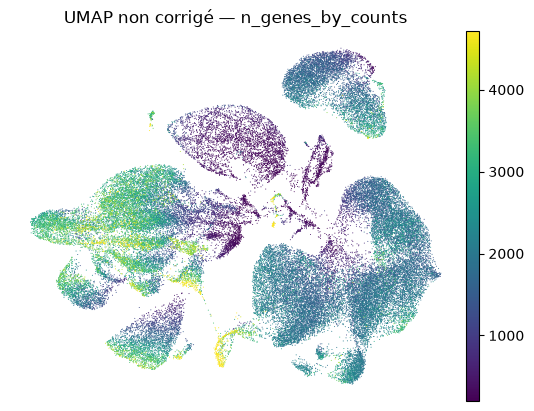

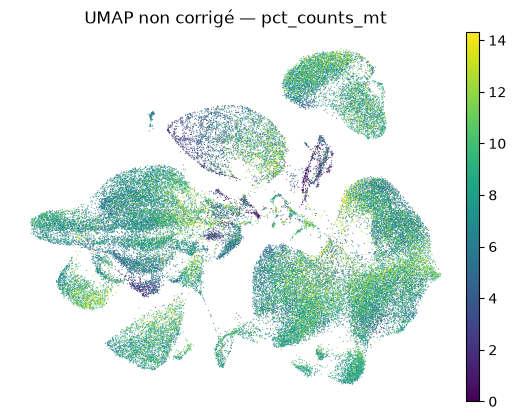

In [10]:
import matplotlib.pyplot as plt

umap_figure_dir = Path("../results/figures/umap")
umap_figure_dir.mkdir(parents=True, exist_ok=True)
umap_colors = [
    "sample_id", "disease", "severity",
    "total_counts", "n_genes_by_counts", "pct_counts_mt",
]
continuous_vmax = {
    "total_counts": "p99",
    "n_genes_by_counts": "p99",
    "pct_counts_mt": "p99",
}

for color_variable in umap_colors:
    plot_kwargs = {
        "color": color_variable,
        "title": f"UMAP non corrigé — {color_variable}",
        "show": False,
        "frameon": False,
    }
    if color_variable in continuous_vmax:
        plot_kwargs.update(vmax=continuous_vmax[color_variable], color_map="viridis")
    ax = sc.pl.umap(adata, **plot_kwargs)
    ax.figure.savefig(
        umap_figure_dir / f"umap_uncorrected_{color_variable}.png",
        dpi=300, bbox_inches="tight",
    )
    plt.show()
    plt.close(ax.figure)

## Comment lire cet UMAP

Chaque point représente une cellule. Les axes UMAP1 et UMAP2 n'ont pas de signification biologique intrinsèque et leur orientation est arbitraire. La proximité locale entre cellules est généralement plus interprétable que les distances globales entre des régions éloignées de la projection. Une séparation visuelle par sample_id est rapportable, mais ne constitue pas automatiquement une preuve d'effet de batch.

## Sauvegarde de l'objet avec graphe et UMAP

In [11]:
output_path = Path("../data/processed/GSE149689_neighbors_umap_uncorrected.h5ad")
temporary_output_path = output_path.with_suffix(".tmp.h5ad")
adata.write_h5ad(temporary_output_path)
temporary_output_path.replace(output_path)
print("Objet sauvegardé :", output_path)
print("Dimensions :", adata.shape)
print("X_pca :", adata.obsm["X_pca"].shape)
print("X_umap :", adata.obsm["X_umap"].shape)
print("Taille du fichier :", output_path.stat().st_size, "octets")

Objet sauvegardé : ../data/processed/GSE149689_neighbors_umap_uncorrected.h5ad
Dimensions : (58825, 33538)
X_pca : (58825, 50)
X_umap : (58825, 2)
Taille du fichier : 1842345799 octets


Le premier UMAP non corrigé a été calculé une seule fois à partir du graphe de 15 voisins construit sur 20 PC. Les mêmes coordonnées ont été utilisées pour toutes les colorations. Aucun Leiden, clustering, annotation automatique, test différentiel ou correction de batch n'a été réalisé.